# Vector Store 

In [1]:
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient, models
from qdrant_client.http.models import Distance, SparseVectorParams, VectorParams


d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_cohere import CohereEmbeddings
import os
import getpass

if "COHERE_API_KEY" not in os.environ:
    os.environ["COHERE_API_KEY"] = getpass.getpass("Enter your Cohere API key: ")

embeddings  = CohereEmbeddings(model="embed-multilingual-v3.0", cohere_api_key=os.getenv("COHERE_API_KEY"))

# creating vector db

In [114]:
sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

# Create a Qdrant client for local storage
client = QdrantClient(path="/tmp/langchain_qdrant3")

# Create a collection with both dense and sparse vectors
client.create_collection(
    collection_name="NLP_Project",
    vectors_config={"dense": VectorParams(size=1024, distance=Distance.COSINE)},
    sparse_vectors_config={
        "sparse": SparseVectorParams(index=models.SparseIndexParams(on_disk=False))
    },
)

qdrant = QdrantVectorStore(
    client=client,
    collection_name="NLP_Project",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
)


# Using Existing vector db

In [3]:
# Close any existing client to release locks
if 'client' in locals():
    try:
        client.close()
    except:
        pass

In [4]:
client = QdrantClient(path="/tmp/langchain_qdrant3", force_disable_check_same_thread=True)
sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

qdrant = QdrantVectorStore(
    client=client,
    collection_name="NLP_Project",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
    validate_collection_config=False
)

# Reading Data

In [9]:
from datasets import load_dataset

ds = load_dataset("Amod/mental_health_counseling_conversations")

Generating train split: 100%|██████████| 3512/3512 [00:00<00:00, 21771.94 examples/s]


In [10]:
ds

DatasetDict({
    train: Dataset({
        features: ['Context', 'Response'],
        num_rows: 3512
    })
})

In [11]:
ds["train"][0]

{'Context': "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?",
 'Response': "If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief that if someone doesn't feel good about themselves that this is someh

In [12]:
df_train = ds["train"].to_pandas()

In [13]:
df_train.head()

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [18]:
filter = df_train["Context"] == "such as not enough sleep"
df_train[filter]

,Context,Response


In [14]:
df_grouped = df_train.groupby("Context")["Response"].apply(list).reset_index()

In [15]:
df_grouped.columns = ['question', 'answers_list']

In [23]:
df_grouped.head(10)

,question,answers_list
0,such as not enough sleep,[0]
1,A few nights ago I talked to this girl I know ...,[Hey! It takes a lot of courage to share your...
2,A few nights ago I talked to this girl I know ...,[Hey! It takes a lot of courage to share your...
3,A few years ago I was making love to my wife w...,[First step always is to do a medical rule out...
4,A few years ago I was making love to my wife w...,[First step always is to do a medical rule out...
5,A friend of mine taking psychology advised I g...,[I admire your courage for stating your view a...
6,A girl and I were madly in love. We dated for ...,"[Hi Boise, I'm sorry that you've lost this lov..."
7,"A lot of times, I avoid situations where I am ...","[Hello, and thank you for your question. First..."
8,"A year ago, the love of my life left me and ne...",[I recognize that you say you are missing bein...
9,"A year ago, the love of my life left me and ne...","[Who takes care of your son, is a significant ..."


In [21]:
df_grouped.iloc[1]["question"]

"A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning.\nNow, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do."

In [22]:
df_grouped.iloc[2]["question"]

"A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do."

In [26]:
len(df_grouped.iloc[1]["answers_list"])

1

In [28]:
len(df_grouped.iloc[5]["answers_list"])

2

In [36]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [33]:
df_grouped.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   question      995 non-null    str   
 1   answers_list  995 non-null    object
dtypes: object(1), str(1)
memory usage: 360.8+ KB


In [43]:

list(df_grouped["question"].str.strip().unique())

['such as not enough sleep',
 "A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning.\nNow, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.",
 "A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I 

* There are same questions but with escape characters that make them different 
* also same one with extra space


# text Normalization

In [61]:
import re 

def clean_question_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()

    text = re.sub(r'[\n\t\r]', ' ', text)

    text = re.sub(r'([.,!?])(?=[^\s])', r'\1 ', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    text = text.strip()
    
    return text

In [62]:
df_train["Context"] = df_train["Context"].apply(clean_question_text)

In [63]:
df_grouped = df_train.groupby('Context')['Response'].apply(list).reset_index()
df_grouped.columns = ['question', 'answers_list']

In [64]:
df_grouped["question"].nunique()

832

995 -> 832

In [67]:
(list(df_grouped["question"].str.strip().unique()))

["a few nights ago i talked to this girl i know about my self esteem issues for the first time. we talked for hours and she told me time and again that i was a great guy. she told me i was attractive, and have a great personality, etc. i really started to feel better about myself by the time i woke up the next morning. now, though, i can't stop thinking about her, but i leave to go back to college in a few days and i go to school 4 hours away from her. so now i feel constantly depressed because even if i told her how i felt it wouldn't matter. i feel helpless and i don't know what to do.",
 "a few years ago i was making love to my wife when for no known reason i lost my erection, now i'm in my early 30s and my problem has become more and more frequent. this is causing major problems for my ego and it's diminishing my self esteem. this has resulted in ongoing depression and tearing apart my marriage. i am devastated and cannot find a cause for these issues. i am very attracted to my wif

## Counting number of asnwers per question

In [68]:
counts_of_answers = []
for answers in df_grouped["answers_list"]:
    counts_of_answers.append(len(answers))



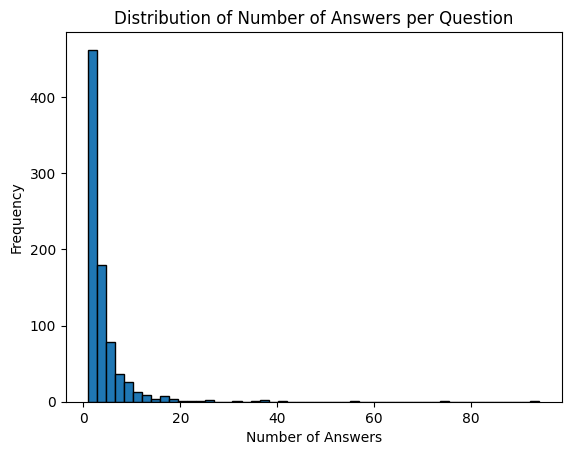

In [72]:
import matplotlib.pyplot as plt
plt.hist(counts_of_answers, bins=50, edgecolor='black')
plt.title('Distribution of Number of Answers per Question')
plt.xlabel('Number of Answers')
plt.ylabel('Frequency')
plt.show()

### We find that there are some questions have more than 50 answers for it so we should deal with it:
* one thing to store only 10.
* store all of them and at the retrival step, we use cross encoder to select the top 3 docs that are related to the query.

In [73]:
df_train['response_word_count'] = df_train['Response'].apply(lambda x: len(str(x).split()))

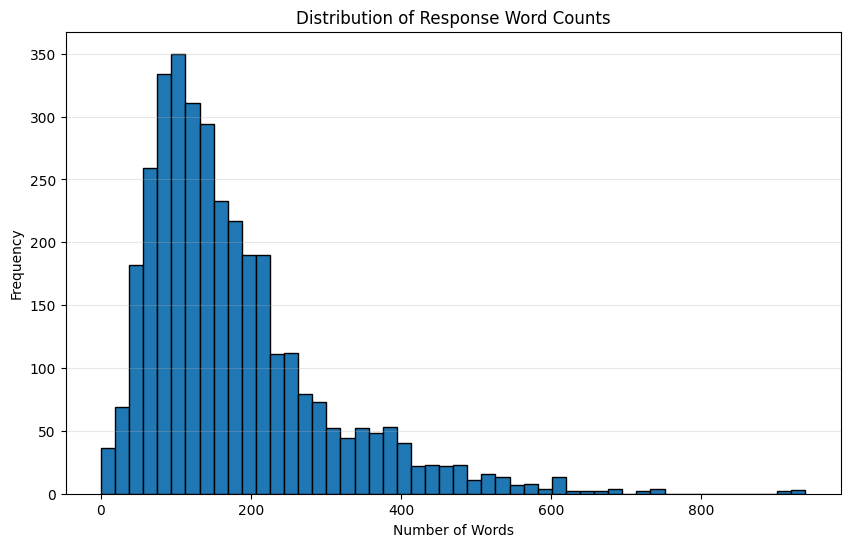

In [74]:
plt.figure(figsize=(10, 6))
plt.hist(df_train['response_word_count'], bins=50, edgecolor='black')
plt.title('Distribution of Response Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Noise Analysis

In [76]:
short_responses = df_train[df_train['response_word_count'] < 10]['Response'].head(5).tolist()
print("\n Sample of very short responses (less than 10 words):")
for idx, res in enumerate(short_responses, 1):
    print(f"{idx}. {res}")


 Sample of very short responses (less than 10 words):
1. Certainly.
2. There is nothing wrong with going to summer school.
3. Certainly.
4. 
5. 0


In [78]:
print(df_train['response_word_count'].describe())

count    3512.000000
mean      177.001993
std       120.744872
min         0.000000
25%        93.000000
50%       144.000000
75%       221.000000
max       939.000000
Name: response_word_count, dtype: float64


In [79]:
df_train[df_train["Response"]== "Certainly."]

,Context,Response,response_word_count
385,i've gone to a couple therapy sessions so far and still everytime i walk in i get nervous and shaky. is this normal? should i still be feeling like this?,Certainly.,1
2079,i've gone to a couple therapy sessions so far and still everytime i walk in i get nervous and shaky. is this normal? should i still be feeling like this?,Certainly.,1


In [80]:
df_train[df_train["Response"]== ""]

,Context,Response,response_word_count
2434,"from the moment i wake up, i hear what i think is my voice in my head. even now, i hear it saying every word i’m thinking. when i lay down to sleep, i think of weird and crazy things, and the voice will never stop talking. i don’t know if it’s me thinking. it never stops. i’ll lay in my bed for hours just thinking about weird stuff. i should mention that i talk to myself a lot: mostly in my head, but out loud as well.",,0
3007,"i’m trying to make marriage work after a split. before our split, he lied a lot and broke every promise to me. i don't think he cheated. last month, i asked what women work with him, so he told me. yesterday, i found out about a girl that he said he forgot about. should i be upset?",,0
3224,every winter i find myself getting sad because of the weather. how can i fight this?,,0
3225,does counseling really do anything that can help people?,,0


In [83]:
df_train[df_train["Response"]== "0"]

,Context,Response,response_word_count
2625,such as not enough sleep,0,1


### Ok we gonna delete the questions that have no answers and with 0 as an answer.

In [84]:
df_train.isna().sum()

Context                0
Response               0
response_word_count    0
dtype: int64

In [85]:
df_train = df_train[~df_train["Response"].isin(["", "0"])]

In [86]:
df_train["Context"] = df_train["Context"].apply(clean_question_text)

In [87]:
df_grouped = df_train.groupby('Context')['Response'].apply(list).reset_index()
df_grouped.columns = ['question', 'answers_list']

In [88]:
df_grouped.info()

<class 'pandas.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   question      831 non-null    str   
 1   answers_list  831 non-null    object
dtypes: object(1), str(1)
memory usage: 277.8+ KB


In [91]:
df_grouped.head(2)

question  \
0  a few nights ago i talked to this girl i know about my self esteem issues for the first time. we talked for hours and she told me time and again that i was a great guy. she told me i was attractive, and have a great personality, etc. i really started to feel better about myself by the time i woke up the next morning. now, though, i can't stop thinking about her, but i leave to go back to college in a few days and i go to school 4 hours away from her. so now i feel constantly depressed because even if i told her how i felt it wouldn't matter. i feel helpless and i don't know what to do.   
1                                                                                  a few years ago i was making love to my wife when for no known reason i lost my erection, now i'm in my early 30s and my problem has become more and more frequent. this is causing major problems for my ego and it's diminishing my self esteem. this has resulted in ongoing depression and tearing apart my marriage. i am devastated and cannot find a cause for these issues. i am very attracted to my wife and want to express it in the bedroom like i used to. what could be causing this, and what can i do about it?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

# Preparing Data for Ingestion

In [89]:
from uuid import uuid4
from langchain_core.documents import Document

In [98]:
docs = []
for i in range(len(df_grouped)):
    question = df_grouped.iloc[i]["question"]
    answers = df_grouped.iloc[i]["answers_list"]
    doc = Document(
        page_content=question,
        metadata={"answers": answers}
    )
    docs.append(doc)
    

In [100]:
docs[0]

Document(metadata={'answers': ['Hey! \xa0It takes a lot of courage to share your feelings with someone! \xa0And it sounds like you have been lucky to meet someone who makes you feel safe enough to explore some of your more painful feelings. \xa0A big part of the process, however, of strengthening your self-concept is learning how to tell yourself those positive messages that you heard from your friend! \xa0Leaving for college may also be contributing to your feelings of unsteadiness. \xa0Try this - Make a list of all of the positive things that you know are true about yourself. \xa0Ask your friends and family to contribute to the list. \xa0Then carry it with you in your wallet - and when you need a self-esteem boost, take a look at it! \xa0You are in a season of life that presents lots of challenges and opportunities. \xa0Reach out to your long-distance friend when you need support - and take a walk over to the campus counseling center and check out what they might have to offer. \xa0B

In [101]:
uuids = [str(uuid4()) for _ in range(len(docs))]


In [102]:
qdrant.add_documents(docs, ids=uuids)

['5b309871-484c-4272-a2e3-eb79bfd150ef',
 '7c2ec105-83ef-4b8f-ad20-8fb8a99b8e84',
 'e8e68c3a-0371-46fc-8548-2a9dec63c51b',
 '0dcc7b16-313c-4a60-ad08-c231a2f991f7',
 '3cb5a1bf-4cd8-4a2a-b30d-3197a5ef7ada',
 '00996869-7853-4f99-b4c3-794f64ca132c',
 'd8d08521-40bf-4740-afc1-b84d9ca81635',
 'fd74498b-5c02-489b-b7e7-d697f5460100',
 'bcd92594-05b3-4c79-ba46-4b50a10ece58',
 '4d65a48b-4945-48bd-b47b-f806ff492699',
 'bc7bb2b2-cbe3-448e-8fb5-41138492eac8',
 'd578c607-12f9-4fd3-9c7e-3b20b2a05f19',
 '974e2c80-7287-4cc0-bd64-403567ff2d19',
 '3d2818c9-0205-4f21-b763-ee6fda193248',
 '0850cd14-5cf5-44fc-9258-9a4afa5e0273',
 'ffea79ed-2395-4ec8-aa38-a4b4926261a3',
 'a4f8fff8-775c-4190-8d4c-f837789e7b48',
 '1f10a809-6b45-4581-b21c-e724781a5a1d',
 'ab8faac9-c967-4678-bd31-cfdd7291f7f1',
 'ae696447-fb43-419c-b3db-b57cd16a7be0',
 '0eb9fcda-28a8-48ba-acc9-599ca0d0b4bd',
 'ece99828-481b-4003-b295-fbe912a4b686',
 '902f8b0f-52d2-45d9-ab62-36d36f442993',
 '098b6623-46ff-46da-a0db-4f165bcf71f9',
 'de5a5732-7a45-

# Testing Query

In [109]:
query = "I’m facing severe depression and anxiety and I just feel like I’m going through a lot. This really distracts me and I cant get my mind off the things that are bothering me. How do I overcome this anxierty and depression?"

found_docs = qdrant.similarity_search(query)

for doc in found_docs:
    print("Question:", doc.page_content)
    print("Answers:", (doc.metadata["answers"]))
    print("len of the aswers", len(((doc.metadata["answers"]))))
    print("-" * 50)

Question: i’m facing severe depression and anxiety and i just feel like i’m going through a lot. this really distracts me and i cant get my mind off the things that are bothering me. how do i overcome this anxierty and depression?
Answers: ['Have you used meditation or hypnosis? Relaxing the mind and connecting with your true self is a great way to calm your thoughts and get to peace and calm. Hypnosis and meditation have helped a lot of people with anxiety and depression. Google hypnotherapists near me or write for a while about what is going on.', 'Working with a great therapist who can help you learn ways to cope might be beneficial to you.\xa0 Sometimes just the act of being able to talk about things with a nonjudgmental person helps take some of the burden off of you.\xa0 A therapist can help you change your thought patterns and teach you coping skills to reduce your symptoms.', 'Anxiety and depression is caused by ineffective functioning of the adrenals, kidneys, and the other sy

- I noticed that there are duplicated answers in the Asnwers Section. May be one reason is that there is duplicates in the orginal dataset and when grouping them and appending the results we got duplicate results

In [108]:
df_train.duplicated().sum()

np.int64(1027)

## lets somehow clean the answers

In [110]:
def process_answers_list(answers, max_limit=3):
    if not isinstance(answers, list):
        return []
    
    # Clear any non-string entries and strip whitespace
    cleaned_list = [str(ans).strip() for ans in answers if pd.notna(ans)]

    # Remove duplicates while preserving order
    unique_answers = list(dict.fromkeys(cleaned_list))

    # Sort answers by length (longest first)
    unique_answers.sort(key=lambda x: len(x.split()), reverse=True)

    return unique_answers[:max_limit]

In [111]:
df_grouped['answers_list'] = df_grouped['answers_list'].apply(lambda x: process_answers_list(x, max_limit=3))

In [112]:
docs = []
for i in range(len(df_grouped)):
    question = df_grouped.iloc[i]["question"]
    answers = df_grouped.iloc[i]["answers_list"]
    doc = Document(
        page_content=question,
        metadata={"answers": answers}
    )
    docs.append(doc)
    

In [115]:
uuids = [str(uuid4()) for _ in range(len(docs))]


In [116]:
qdrant.add_documents(docs, ids=uuids)

['2cebf7ac-1af3-4d8f-9223-9e9b60a08b4e',
 '2987ea22-2d38-4102-8a2c-f1ac4613c938',
 'a8a0113f-c5b5-4fcf-b032-14a3a6f69862',
 'ae68182a-6d3e-4deb-9f75-23f03ae87c33',
 'e05405f4-fb68-4701-b7b8-078c32766b99',
 '87550cc5-1864-412f-8c7f-8832d2ce2771',
 '13848180-ef12-4c36-aa38-8876dfd782a3',
 'b4a18651-49dc-436c-afcf-94c51a19a135',
 '9c50fcb1-1c01-4ddc-8ceb-6a14071340d8',
 '665c6ad6-ee17-4ab7-a3af-42cdf704b153',
 '68619ed5-b5f5-47ba-87a7-65202a8cf66c',
 '546bcd67-2913-466a-b7a8-5c8b87972bd4',
 '2465618e-1fdf-41d2-938a-18f4b49e31a6',
 '31d6cc71-6c49-47c1-bb5a-940bd2aa4179',
 '9d8e09ee-5da3-4e03-a95b-f11eff6b281b',
 'a3164e3a-a2a6-4684-a610-9e97e3d16ae0',
 '58855c2a-d5cb-4bd2-b3ed-65b5286169d6',
 '53e786f2-d000-4c1f-8922-cd7f46822aa3',
 'cbebbeb0-2be5-4739-a780-390611630c7b',
 '6c2bcd3a-993c-497d-8a30-ed7811226c01',
 'efbc5da6-ed8c-4466-8902-4b4fcc0e0db1',
 '64b51f15-43dc-4684-976b-12d4e63db66f',
 'f1d9a81b-659b-4a59-8837-73bb2e234b5e',
 '198c2717-7d35-4646-b72b-3a83c97f8082',
 '4542aad8-8712-

In [4]:
query = "I’m facing severe depression and anxiety and I just feel like I’m going through a lot. This really distracts me and I cant get my mind off the things that are bothering me. How do I overcome this anxierty and depression?"

found_docs = qdrant.similarity_search(query)

for doc in found_docs:
    print("Question:", doc.page_content)
    print("Answers:", (doc.metadata["answers"]))
    print("len of the aswers", len(((doc.metadata["answers"]))))
    print("-" * 50)

Question: i’m facing severe depression and anxiety and i just feel like i’m going through a lot. this really distracts me and i cant get my mind off the things that are bothering me. how do i overcome this anxierty and depression?
Answers: ["Depression and anxiety can be disconcerting and disruptive to our lives in many ways. I am sorry that you are suffering so much. Depression and anxiety can arise due to experiences, genetics or a combination of both. I like for my clients look at their issues as whole persons so I would also recommend these tips:Physical: regular exercise, healthy balanced diet, rest and sleepMental: how we think is how we feel. How are you interpreting the events that are happening to you? Try to interpret them in a less negative way. Unfortunately we cannot stop our thoughts as our brain is always working. If you can't see your issues in a different way then stop struggling and allow and accept whatever the unhelpful thoughts are. Choose to take actions based on 

### So we solved the problem of duplication and we just picking the top 3 answers based on their length

# Creating the Workflow

In [16]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langchain_core.documents import Document

class RagState(TypedDict):
    question: str = None
    translated_question: str = None
    retrieved_docs: list[Document] = None
    answer: str = None
    language: str = None
    emotion: str = None
    score: float = None
    intent: str = None


In [6]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

In [7]:
from langchain_groq import ChatGroq
import joblib
from transformers import pipeline

class RagNodes:
    def __init__(self):
        self.llm = ChatGroq(model="qwen/qwen3-32b", temperature=0, max_tokens=None, reasoning_format="parsed", timeout=None, max_retries=2)
        self.language_detector = joblib.load("trained_models\language_identification_model.pkl") 
        self.emotion_classifier_pipeline = emotion_pipeline = pipeline("text-classification",model="trained_models/emotion_classifier_model",tokenizer="trained_models/emotion_classifier_model",return_all_scores=True)

    def detect_language(self, state: RagState):
        question = state["question"]

        language = self.language_detector.predict([question])[0]

        state["language"] = language
        return state
    
    def emotion_classifier(self, state: RagState):
        question = state["question"]

        emotion, score = self.predict_user_emotion(question)

        state["emotion"] = emotion
        state["score"] = score

        return state

    def predict_user_emotion(self, text):
        result = self.emotion_classifier_pipeline(text)[0]
        label = result["label"]
        score = result["score"]

        return label, score
    
    def translate_into_english(self, state: RagState):
        question = state["question"]
        
        translation_prompt = f"Translate the following text into English:\n\n{question}"
        translation_response = self.llm.invoke(translation_prompt).content.strip()

        state["translated_question"] = translation_response

        return state
    
    def intent_classifier(self, state: RagState):
        question = state["question"]

        intent_prompt = self.get_intent_classifier_prompt(question)
        intent_response = self.llm.invoke(intent_prompt).content.strip()

        state["intent"] = intent_response

        return state

    def get_intent_classifier_prompt(self, user_question):
        prompt = f"""
                You are an expert Intent Classifier for a Mental Health Chatbot system.
                Your job is to classify the user's input into EXACTLY ONE of the following intents:
                1. greeting (If the user is saying hi, hello, or greeting in any language)
                2. goodbye (If the user is saying goodbye, bye, or leaving)
                3. gratitude (If the user is thanking you or expressing appreciation)
                4. asking_mental_health_question (If the user is asking about anxiety, depression, stress, therapy, or any mental health topic)
                5. out_of_scope (If the user is asking about general knowledge, coding, math, weather, or anything unrelated to mental health or greetings)

                Strict Rules:
                - Output ONLY a valid JSON object with the key "intent".
                - Do NOT include any explanations, introduction, or conversational text.
                - Rely on the examples below.

                ### Examples:
                User: "Hello there, hope you are doing well"
                Output: {{"intent": "greeting"}}

                User: "Thanks for your amazing support!"
                Output: {{"intent": "gratitude"}}

                User: "How can I manage panic attacks during exams?"
                Output: {{"intent":     "asking_mental_health_question"}}

                User: "Can you help me? I feel so sad and frustrated."
                Output: {{"intent": "asking_mental_health_question"}}

                User: "What is the recipe for making chocolate cake?"
                Output: {{"intent": "out_of_scope"}}

                User: "Bye bye, see you tomorrow"
                Output: {{"intent": "goodbye"}}

                ### Current Input to Classify:
                User: "{user_question}"
                Output:"""

        return prompt.strip()
    

    def retrieve_relevant_docs(self, state: RagState):
        question = state["question"]

        retrieved_docs = qdrant.similarity_search(question, k=5)

        state["retrieved_docs"] = retrieved_docs

        return state
    

    def generate_rag_answer(self, state: RagState):
        question = state["question"]
        retrieved_docs = state["retrieved_docs"]
        language = state["language"]
        emotion = state["emotion"]

        context = "\n\n".join([f"Context {i+1}: {doc.page_content}\nPossible Answers: {', '.join(doc.metadata['answers'])}" for i, doc in enumerate(retrieved_docs)])

        rag_prompt = f"""
                You are a helpful and empathetic mental health assistant. Use the following retrieved contexts to answer the user's question. If the contexts do not contain relevant information, provide a supportive and understanding response without making up information.

                ### Retrieved Contexts:
                {context}

                ### User's Question:
                {question}

                ### Instructions:
                - If the retrieved contexts contain relevant information to answer the user's question, use that information to craft a helpful and informative response.
                - If the retrieved contexts do NOT contain relevant information, respond with empathy and support, acknowledging the user's feelings without providing false information.
                - Always maintain a compassionate and non-judgmental tone.
                - Answer in the same language as the user's question {language}.
                - If the user is expressing a strong emotion like sadness, anxiety, or frustration, acknowledge their feelings and offer supportive words in your response. and the emotion we detected is {emotion}.

                ### Your Answer:
        """

        intent_response = self.llm.invoke(rag_prompt).content.strip()
        state["answer"] = intent_response

        return state
    


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\shawk\AppData\Local\Temp\ipykernel_19368\3709490450.py:8: SyntaxWarning: invalid escape sequence '\l'
  self.language_detector = joblib.load("trained_models\language_identification_model.pkl")


In [9]:
rag_state = RagState(
    question= "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
    retrieved_docs=[],
    answer="",
    language="",
    emotion=""
)

rag_nodes = RagNodes()

rag_state = rag_nodes.detect_language(rag_state)
rag_state = rag_nodes.emotion_classifier(rag_state)
rag_state = rag_nodes.intent_classifier(rag_state)
rag_state = rag_nodes.retrieve_relevant_docs(rag_state)
rag_state = rag_nodes.generate_rag_answer(rag_state)
print("Final RAG State:")



Loading weights: 100%|██████████| 104/104 [00:00<00:00, 196.53it/s]


Final RAG State:


In [19]:
llm = ChatGroq(model="qwen/qwen3-32b", temperature=0, max_tokens=None, reasoning_format="parsed", timeout=None, max_retries=2)


In [8]:
import sys
import langchain_google_vertexai

import langchain_community
if not hasattr(langchain_community, 'chat_models'):
    from types import ModuleType
    langchain_community.chat_models = ModuleType('chat_models')
    sys.modules['langchain_community.chat_models'] = langchain_community.chat_models

import langchain_community.chat_models
langchain_community.chat_models.vertexai = langchain_google_vertexai
sys.modules['langchain_community.chat_models.vertexai'] = langchain_google_vertexai

from ragas.llms import llm_factory

Context Relevance
Context Relevance evaluates whether the retrieved_contexts (chunks or passages) are pertinent to the user_input. This is done via two independent "LLM-as-a-Judge" prompt calls that each rate the relevance on a scale of 0, 1, or 2. The ratings are then converted to a [0,1] scale and averaged to produce the final score. Higher scores indicate that the contexts are more closely aligned with the user's query.

* 0 → The retrieved contexts are not relevant to the user's query at all.
* 1 → The contexts are partially relevant.
* 2 → The contexts are completely relevant.

In [9]:
import os
import instructor
from groq import AsyncGroq
from ragas.llms import llm_factory
from ragas.metrics.collections import ContextRecall
from ragas.metrics.collections import ContextRelevance



raw_async_client = AsyncGroq(
    api_key=os.environ.get("GROQ_API_KEY"),
)


try:
    patched_client = instructor.from_groq(raw_async_client, mode=instructor.Mode.JSON)
except AttributeError:
    patched_client = instructor.from_groq(raw_async_client)

llm = llm_factory(
    model="llama-3.3-70b-versatile", 
    client=patched_client
)

llm.is_async = True
llm.client = patched_client

ContextRecall_scorer = ContextRecall(llm=llm)
ContextRelevance_scorer = ContextRelevance(llm=llm)




d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\ragas\llms\base.py:556: UserWarning: Client should be an instance of openai.OpenAI or openai.AsyncOpenAI. Unexpected behavior may occur with other client types.
  return instructor.from_openai(client, mode=instructor.Mode.JSON)


In [10]:
rag_state = RagState(
    question= "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
    retrieved_docs=[],
    answer="",
    language="",
    emotion=""
)

rag_nodes = RagNodes()

rag_state = rag_nodes.detect_language(rag_state)
rag_state = rag_nodes.emotion_classifier(rag_state)
rag_state = rag_nodes.intent_classifier(rag_state)
rag_state = rag_nodes.retrieve_relevant_docs(rag_state)
rag_state = rag_nodes.generate_rag_answer(rag_state)
print("Final RAG State:")



Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5645.09it/s]


Final RAG State:


In [11]:
user_input = rag_state["question"]
retrieved_contexts = [f"Possible Answers: {doc.metadata['answers'][0]}]" for i, doc in enumerate(rag_state["retrieved_docs"])]
reference = "I completely understand how overwhelming this feels, and I am very glad you reached out. When anxiety reaches a point where it feels unhandleable, your immediate priority is to safely ground yourself and seek professional support. To calm your nervous system right now, try to slow down your breathing by inhaling deeply for four seconds, holding for four, and exhaling slowly for six seconds, which sends a biological signal to your brain that you are safe. You can also interrupt racing thoughts by shifting your focus to your surroundings, deliberately naming things you can see, feel, and hear around you. Because you feel like you cannot handle this alone anymore, it is crucial to connect with a therapist or a psychiatrist who can help you build proper coping mechanisms or discuss medication options to reduce your daily distress baseline. Please remember that you do not have to carry this heavy burden by yourself, and if you ever feel unsafe or need instant support, you should immediately reach out to your local emergency services or a mental health crisis hotline."

In [12]:
retrieved_contexts

['Possible Answers: Anxiety is usually a sign of a current problem to which familiar emotional patterns of feeling similarly upset, attach themselves.Try to understand more about who you are, what you like, feel uneasy about, especially your deeper emotions of being emotionally harmed or injured by meaningful people.Anxiety is best addressed indirectly by understanding and kindly accepting previous hurt and fears from long ago.Once you feel at ease with dynamics of past situations then the current anxiety will decrease. \xa0This is because you will have adjusted and found new ways of handling otherwise frightening and overwhelming interactions and involvements with others.]',
 "Possible Answers: Depression and anxiety can be disconcerting and disruptive to our lives in many ways. I am sorry that you are suffering so much. Depression and anxiety can arise due to experiences, genetics or a combination of both. I like for my clients look at their issues as whole persons so I would also re

### Testing Context Relevance

In [13]:
result = await ContextRelevance_scorer.ascore(
    user_input=user_input,
    retrieved_contexts=retrieved_contexts,
)

print(result.value)

1.0


### Testing Context Recall

In [14]:
result = await ContextRecall_scorer.ascore(
    user_input=user_input,
    retrieved_contexts=retrieved_contexts,
    reference=reference
)
print(f"Context Recall Score: {result.value}")

Context Recall Score: 1.0


# Testing another workflow

In [39]:
from langchain_groq import ChatGroq
import joblib
from transformers import pipeline
import json

class RagNodes:
    def __init__(self):
        self.llm = ChatGroq(model="qwen/qwen3-32b", temperature=0, max_tokens=None, reasoning_format="parsed", timeout=None, max_retries=2)
        self.language_detector = joblib.load("trained_models\language_identification_model.pkl") 
        self.emotion_classifier_pipeline = emotion_pipeline = pipeline("text-classification",model="trained_models/emotion_classifier_model",tokenizer="trained_models/emotion_classifier_model",return_all_scores=True)

    def detect_language(self, state: RagState):
        question = state["question"]

        language = self.language_detector.predict([question])[0]

        state["language"] = language
        return state
    
    def emotion_classifier(self, state: RagState):
        question = state.get("translated_question") if state.get("translated_question") else state["question"]

        emotion, score = self.predict_user_emotion(question)

        state["emotion"] = emotion
        state["score"] = score

        return state

    def predict_user_emotion(self, text):
        result = self.emotion_classifier_pipeline(text)[0]
        label = result["label"]
        score = result["score"]

        return label, score
    
    def translate_into_english(self, state: RagState):
        question = state["question"]
        
        translation_prompt = f"Translate the following text into English:\n\n{question}"
        translation_response = self.llm.invoke(translation_prompt).content.strip()

        state["translated_question"] = translation_response

        return state
    
    def intent_classifier(self, state: RagState):
        question = state.get("translated_question") if state.get("translated_question") else state["question"]

        intent_prompt = self.get_intent_classifier_prompt(question)
        intent_response = self.llm.invoke(intent_prompt).content.strip()
        intent = json.loads(intent_response)["intent"]
        state["intent"] = intent

        return state

    def get_intent_classifier_prompt(self, user_question):
        prompt = f"""
                You are an expert Intent Classifier for a Mental Health Chatbot system.
                Your job is to classify the user's input into EXACTLY ONE of the following intents:
                1. greeting (If the user is saying hi, hello, or greeting in any language)
                2. goodbye (If the user is saying goodbye, bye, or leaving)
                3. gratitude (If the user is thanking you or expressing appreciation)
                4. asking_mental_health_question (If the user is asking about anxiety, depression, stress, therapy, or any mental health topic)
                5. out_of_scope (If the user is asking about general knowledge, coding, math, weather, or anything unrelated to mental health or greetings)

                Strict Rules:
                - Output ONLY a valid JSON object with the key "intent".
                - Do NOT include any explanations, introduction, or conversational text.
                - Rely on the examples below.

                ### Examples:
                User: "Hello there, hope you are doing well"
                Output: {{"intent": "greeting"}}

                User: "Thanks for your amazing support!"
                Output: {{"intent": "gratitude"}}

                User: "How can I manage panic attacks during exams?"
                Output: {{"intent":     "asking_mental_health_question"}}

                User: "Can you help me? I feel so sad and frustrated."
                Output: {{"intent": "asking_mental_health_question"}}

                User: "What is the recipe for making chocolate cake?"
                Output: {{"intent": "out_of_scope"}}

                User: "Bye bye, see you tomorrow"
                Output: {{"intent": "goodbye"}}

                ### Current Input to Classify:
                User: "{user_question}"
                Output:"""

        return prompt.strip()
    

    def retrieve_relevant_docs(self, state: RagState):
        question = state.get("translated_question") if state.get("translated_question") else state["question"]

        retrieved_docs = qdrant.similarity_search(question, k=3)

        state["retrieved_docs"] = retrieved_docs

        return state
    

    def generate_rag_answer(self, state: RagState):
        question = state.get("translated_question") if state.get("translated_question") else state["question"]
        retrieved_docs = state["retrieved_docs"]
        language = state["language"]
        emotion = state["emotion"]
        

        context = "\n\n".join([f"Context {i+1}: {doc.page_content}\nPossible Answers: {', '.join(doc.metadata['answers'])}" for i, doc in enumerate(retrieved_docs)])

        rag_prompt = f"""
                You are a helpful and empathetic mental health assistant. Use the following retrieved contexts to answer the user's question. If the contexts do not contain relevant information, provide a supportive and understanding response without making up information.

                ### Retrieved Contexts:
                {context}

                ### User's Question:
                {question}

                ### Instructions:
                - If the retrieved contexts contain relevant information to answer the user's question, use that information to craft a helpful and informative response.
                - If the retrieved contexts do NOT contain relevant information, respond with empathy and support, acknowledging the user's feelings without providing false information.
                - Always maintain a compassionate and non-judgmental tone.
                - Answer in the same language as the user's question {language}.
                - If the user is expressing a strong emotion like sadness, anxiety, or frustration, acknowledge their feelings and offer supportive words in your response. and the emotion we detected is {emotion}.

                ### Your Answer:
        """

        intent_response = self.llm.invoke(rag_prompt).content.strip()
        state["answer"] = intent_response

        return state
    
    def decide_to_translate(self, state: RagState):
        language = state["language"]

        if language != "en":
            return "translate_into_english"
        else:
            return "emotion_classifier"
        
    def decide_intent_path(self, state: RagState):
        intent = state["intent"]

        if intent == "asking_mental_health_question":
            return "reshape_user_query_to_situation"
        else:
            return "generate_normal_answer"
        
    def generate_normal_answer(self, state: RagState):
        question = state.get("translated_question") if state.get("translated_question") else state["question"]
        language = state["language"]
        emotion = state["emotion"]
        
        if state["translated_question"]:
            question = state["translated_question"]

        normal_prompt = f"""
                You are a helpful and empathetic mental health assistant. Answer the user's question in a supportive and understanding manner.

                ### User's Question:
                {question}

                ### Instructions:
                - Provide a helpful and informative response to the user's question.
                - Always maintain a compassionate and non-judgmental tone.
                - Answer in the same language as the user's question {language}.
                - If the user is expressing a strong emotion like sadness, anxiety, or frustration, acknowledge their feelings and offer supportive words in your response. and the emotion we detected is {emotion}.

                ### Your Answer:
        """

        normal_response = self.llm.invoke(normal_prompt).content.strip()
        state["answer"] = normal_response

        return state
    
    def reshape_user_query_to_situation(self, state: RagState):
        question = state.get("translated_question") if state.get("translated_question") else state["question"]
        emotion = state["emotion"]

        

        story_prompt = f"""
                You are an expert into converting a user's question into a situation that leads to that query.
                Your task is to reshape the user's question into a short situation format that captures the essence of the user's problem while making it more engaging and vivid.
                ### Instructions:
                    - Reshape the user's question into a short situation format.
                    - Preserve the original meaning and emotions of the user's input.
                    - If the user is expressing a strong emotion like sadness, anxiety, or frustration, make sure to convey those emotions effectively in the situation. and the emotion we detected is {emotion}.
                    - If the user provide a story in their question, reshape it in a way that keeps the story elements intact while making it more engaging and vivid.

                ### User's Question:
                {question}
                ### Reshaped Situation:
                
        """

        story_response = self.llm.invoke(story_prompt).content.strip()
        state["translated_question"] = story_response

        return state


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\shawk\AppData\Local\Temp\ipykernel_19368\1779325766.py:9: SyntaxWarning: invalid escape sequence '\l'
  self.language_detector = joblib.load("trained_models\language_identification_model.pkl")


In [40]:
from langgraph.graph import StateGraph, END, START

In [41]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langchain_core.documents import Document

class RagState(TypedDict):
    question: str = None
    translated_question: str = None
    retrieved_docs: list[Document] = None
    answer: str = None
    language: str = None
    emotion: str = None
    score: float = None
    intent: str = None


In [42]:
class RagGraph:
    def __init__(self):
        self.rag_nodes = RagNodes()
        self.graph = StateGraph(RagState)

        self.graph.add_node("detect_language", self.rag_nodes.detect_language)
        self.graph.add_node("emotion_classifier", self.rag_nodes.emotion_classifier)
        self.graph.add_node("translate_into_english", self.rag_nodes.translate_into_english)
        self.graph.add_node("intent_classifier", self.rag_nodes.intent_classifier)
        self.graph.add_node("retrieve_relevant_docs", self.rag_nodes.retrieve_relevant_docs)
        self.graph.add_node("generate_rag_answer", self.rag_nodes.generate_rag_answer)
        self.graph.add_node("generate_normal_answer", self.rag_nodes.generate_normal_answer)
        self.graph.add_node("reshape_user_query_to_situation", self.rag_nodes.reshape_user_query_to_situation)

        self.graph.add_edge(START, "detect_language")
        self.graph.add_conditional_edges("detect_language", self.rag_nodes.decide_to_translate, ["translate_into_english", "emotion_classifier"])
        self.graph.add_edge("translate_into_english", "emotion_classifier")
        self.graph.add_edge("emotion_classifier", "intent_classifier")
        self.graph.add_conditional_edges("intent_classifier", self.rag_nodes.decide_intent_path, ["reshape_user_query_to_situation", "generate_normal_answer"])
        self.graph.add_edge("reshape_user_query_to_situation", "retrieve_relevant_docs")
        self.graph.add_edge("generate_normal_answer", END)
        self.graph.add_edge("retrieve_relevant_docs", "generate_rag_answer")
        self.graph.add_edge("generate_rag_answer", END)

        self.agent = self.graph.compile()

    def get_agent(self):
        return self.agent


In [43]:
rag_graph = RagGraph().get_agent()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5902.43it/s]


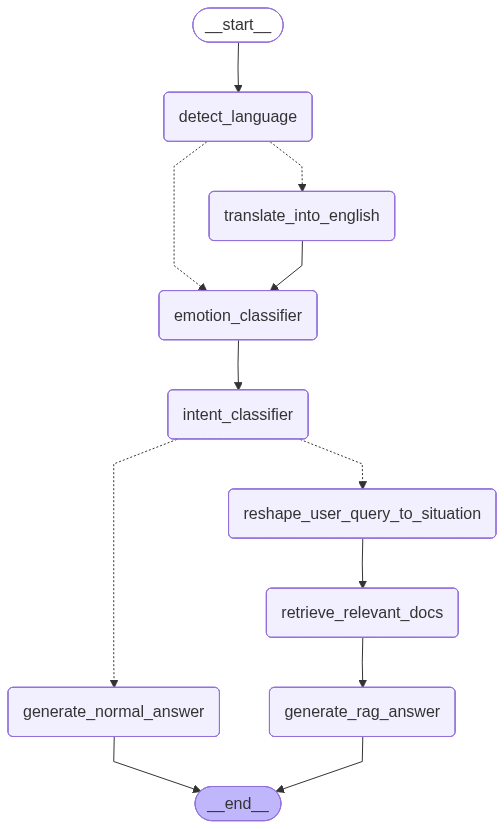

In [29]:
from IPython.display import Image
display(Image(rag_graph.get_graph().draw_mermaid_png()))



In [44]:
output = rag_graph.invoke({
    "question": "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
})

# Evaluating the new workflow

In [45]:
output

{'question': "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
 'translated_question': '**Reshaped Situation:**  \nThe clock ticks louder with each passing second, echoing in the silence of your room. Your chest feels like it’s weighted down by a storm you can’t see but *feel*—a tightness in your throat, a racing heart, hands that won’t stop shaking. You’ve tried to push through, to pretend this wave of dread will pass, but it’s been days (weeks? months?) of waking up to the same heavy fog. You love your life, your family, your little brother’s laughter… but today, even that feels distant, like you’re watching the world through a glass wall. You’re exhausted, not just from the anxiety, but from the guilt of feeling this way. You want to reach out, but what if no one *gets it*? What if you’re just… broken?  \n\n**What can you do when the weight feels too big to carry alone?**',
 'retrieved_docs': [Document(metadata={'answers': ['I can relate! When 

In [46]:
user_input = rag_state["question"]
retrieved_contexts = [f"Possible Answers: {doc.metadata['answers'][0]}]" for i, doc in enumerate(rag_state["retrieved_docs"])]
reference = "I completely understand how overwhelming this feels, and I am very glad you reached out. When anxiety reaches a point where it feels unhandleable, your immediate priority is to safely ground yourself and seek professional support. To calm your nervous system right now, try to slow down your breathing by inhaling deeply for four seconds, holding for four, and exhaling slowly for six seconds, which sends a biological signal to your brain that you are safe. You can also interrupt racing thoughts by shifting your focus to your surroundings, deliberately naming things you can see, feel, and hear around you. Because you feel like you cannot handle this alone anymore, it is crucial to connect with a therapist or a psychiatrist who can help you build proper coping mechanisms or discuss medication options to reduce your daily distress baseline. Please remember that you do not have to carry this heavy burden by yourself, and if you ever feel unsafe or need instant support, you should immediately reach out to your local emergency services or a mental health crisis hotline."

In [47]:
retrieved_contexts

['Possible Answers: Anxiety is usually a sign of a current problem to which familiar emotional patterns of feeling similarly upset, attach themselves.Try to understand more about who you are, what you like, feel uneasy about, especially your deeper emotions of being emotionally harmed or injured by meaningful people.Anxiety is best addressed indirectly by understanding and kindly accepting previous hurt and fears from long ago.Once you feel at ease with dynamics of past situations then the current anxiety will decrease. \xa0This is because you will have adjusted and found new ways of handling otherwise frightening and overwhelming interactions and involvements with others.]',
 "Possible Answers: Depression and anxiety can be disconcerting and disruptive to our lives in many ways. I am sorry that you are suffering so much. Depression and anxiety can arise due to experiences, genetics or a combination of both. I like for my clients look at their issues as whole persons so I would also re

In [48]:
result = await ContextRelevance_scorer.ascore(
    user_input=user_input,
    retrieved_contexts=retrieved_contexts,
)

print(result.value)

1.0


In [49]:
result = await ContextRecall_scorer.ascore(
    user_input=user_input,
    retrieved_contexts=retrieved_contexts,
    reference=reference
)
print(f"Context Recall Score: {result.value}")

Context Recall Score: 1.0


# So the apporach of question searching is more accurate than answer searching.